
Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.05
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
PINN | Split  1/5 | Epoch     1/2000 | Train Total: 5.975843e-01 | Train Data: 5.933917e-01 | Train Phys: 4.192628e-03 | Train Anchor: 1.406801e-02 | Heldout Rollout Val: 3.510492e-01
PINN | Split  1/5 | Epoch   500/2000 | Train Total: 3.471614e-03 | Train Data: 3.094678e-03 | Train Phys: 3.769359e-04 | Train Anchor: 3.236657e-03 | Heldout Rollout Val: 1.285261e-02
PINN | Split  1/5 | Epoch  1000/2000 | Train Total: 2.557227e-03 | Train Data: 2.427479e-03 | Train Phys: 1.297482e-04 | Train Anchor: 3.648925e-04 | Heldout Rollout Val: 6.839812e-03
PINN | Split  1/5 | Epoch  1500/2000 | Train Total: 2.460895e-03 | Train Data: 2.353763e-03 | Train Phys: 1.071322e-04 | Train Anchor: 5.434628e-05 | Heldout Rollout Val: 4.170711e-03
PINN | Split  1/5 | Epoch  2000/2000 | Train 

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_64893/2121162323.py:137: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)


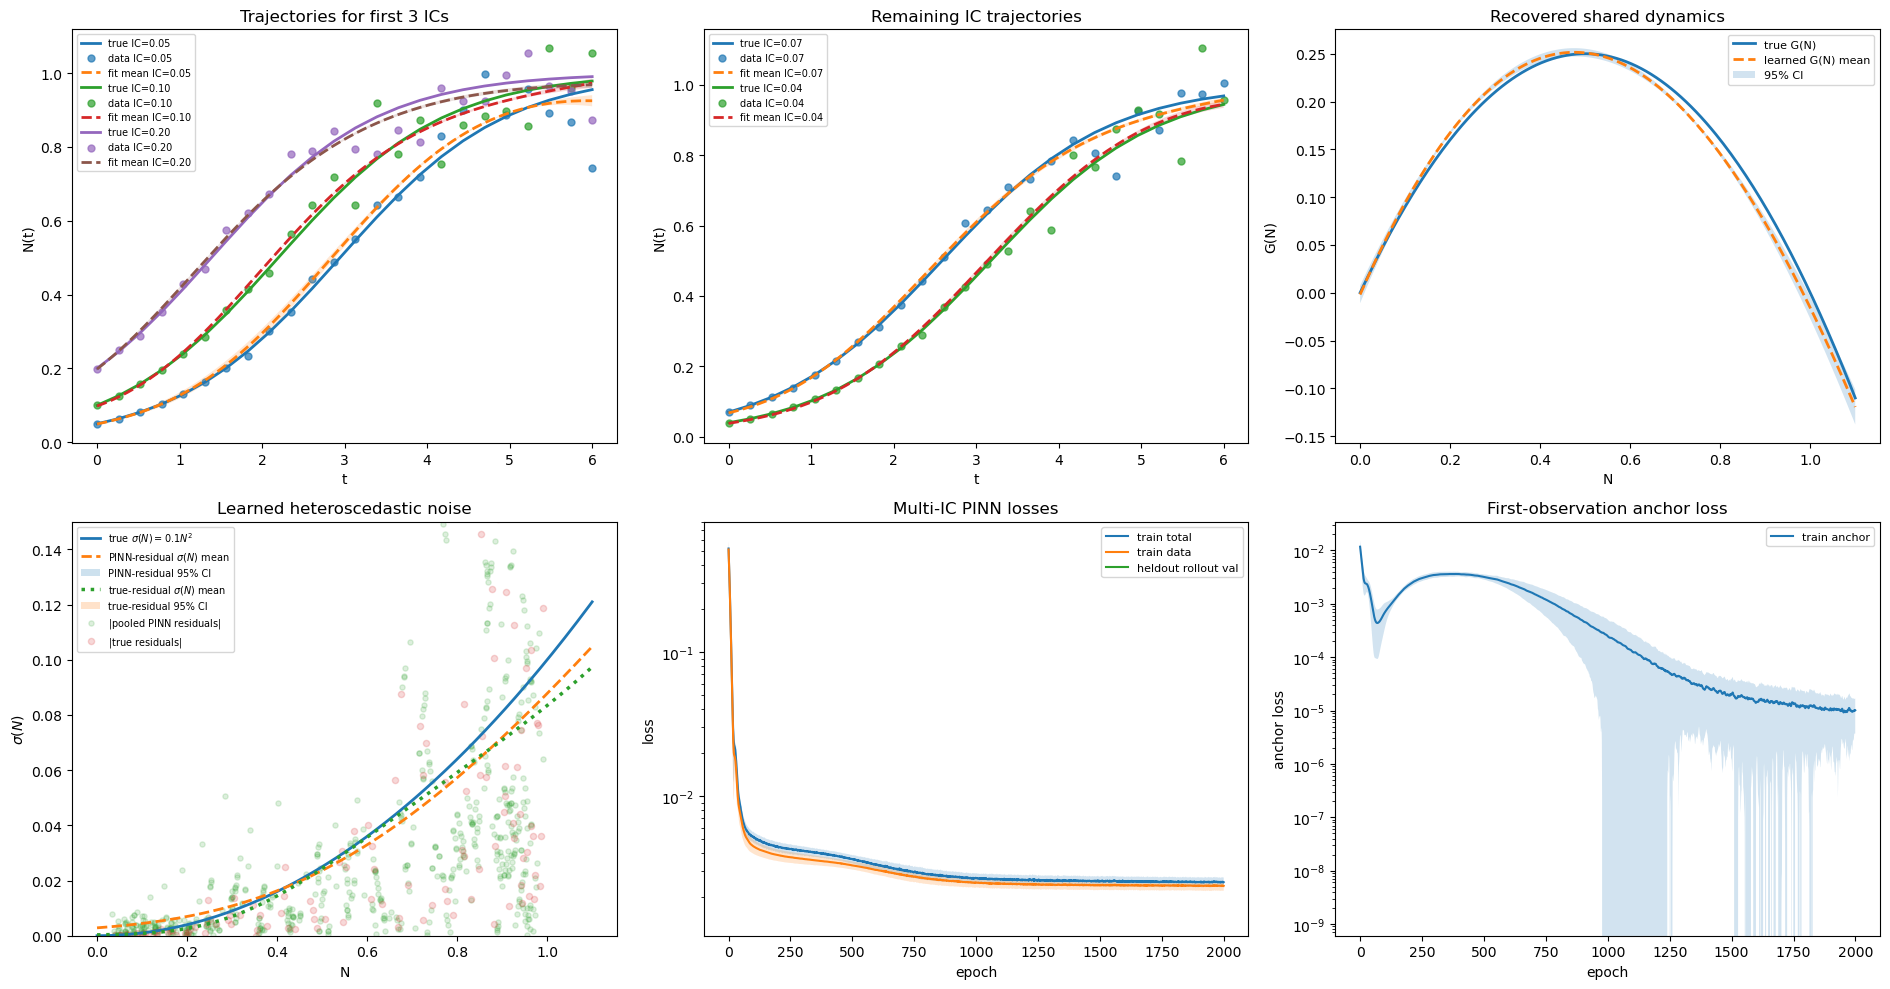

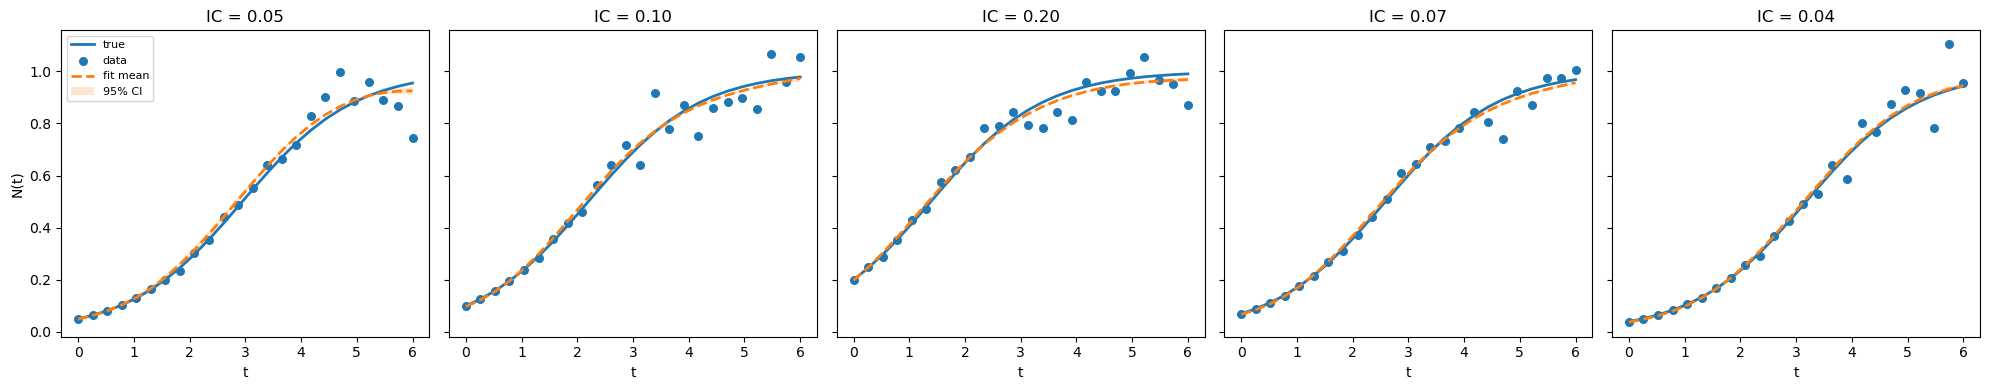

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_64893/2121162323.py:1012: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


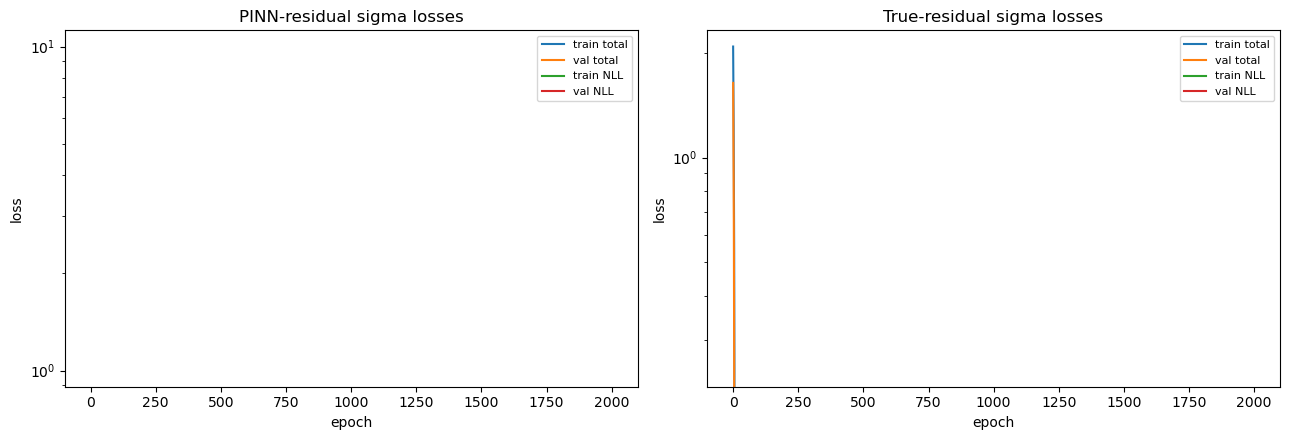


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 2.849495e-03
Std  best validation loss: 9.805509e-04
Mean best epoch: 1639.00
Std  best epoch: 378.15
Anchor weight lambda_anchor: 0.000

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004]
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_seeds=[21000, 21002, 21003, 21004]
Split 3: heldout_ic=2, dyn_init_seed=10002, sol_init_seeds=[22000, 22001, 22003, 22004]
Split 4: heldout_ic=3, dyn_init_seed=10003, sol_init_seeds=[23000, 23001, 23002, 23004]
Split 5: heldout_ic=4, dyn_init_seed=10004, sol_init_seeds=[24000, 24001, 24002, 24003]

PINN-residual s

In [7]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04]#, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N^2
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = np.nanmean(arr, axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        std = np.nanstd(arr, axis=0, ddof=1)
        n_eff = np.sum(~np.isnan(arr), axis=0)
        sem = np.divide(std, np.sqrt(np.maximum(n_eff, 1)), where=n_eff > 0)
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 2000
n_splits = n_ics                 # one held-out trajectory per split
print_every = 500
val_every = 100                  # expensive rollout-based validation cadence

batch_obs = t_obs.shape[0]       # use all observation times for each training trajectory
batch_col = 100

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across training ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        # ----------------------------------------------------
        # Train only on non-held-out trajectories
        # ----------------------------------------------------
        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            # observation mini-batch from this trajectory
            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # optional anchor to first observed point
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_anchor_loss /= n_train_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        # ----------------------------------------------------
        # Held-out trajectory validation via forward rollout
        # ----------------------------------------------------
        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                # start held-out rollout from its first observed value
                y0_val = y_data_all[heldout_ic][0:1]            # shape [1, 1]
                y_val_target = y_data_all[heldout_ic]           # shape [numpts, 1]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"Train Total: {train_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train Anchor: {total_anchor_loss.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                # held-out trajectory comes purely from forward solve of learned RHS
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
#    Note: for held-out trajectories inside each split, N_hat comes from
#          forward solving the learned RHS, not a solution net.
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

Number of non-empty PINN bins: 27
Bin counts: [ 1 29 33 22 20 24 21 13 17 18  7 23 12 15 16  9 23 15 14 23 23 28 34 44
 69 46  1]


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.945e-04  1.594e+01  y = 0.031508
3           1.157e-04  8.182e-01  y = x₀ * 0.058289
5           7.816e-05  1.963e-01  y = (x₀ * 0.07054) * x₀
7           7.576e-05  1.556e-02  y = 0.0025043 - (x₀ * (x₀ * -0.066965))
9           7.504e-05  4.812e-03  y = x₀ * (((x₀ * -0.029608) + 0.096428) * x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic expression for PINN empirical mean residual:
complexity                                       5
loss                                      0.000078
equation                    (x0 * 0.07053965) * x0
score                                     0.196272
sympy_format                      x0*0.07053965*x0
lambda_format    PySRFunction(X=>x0*0.07053965*x0)
Name: 2, dtype: object
ideal value 0.7978845608028654

Sympy form:
x0*0.07053965

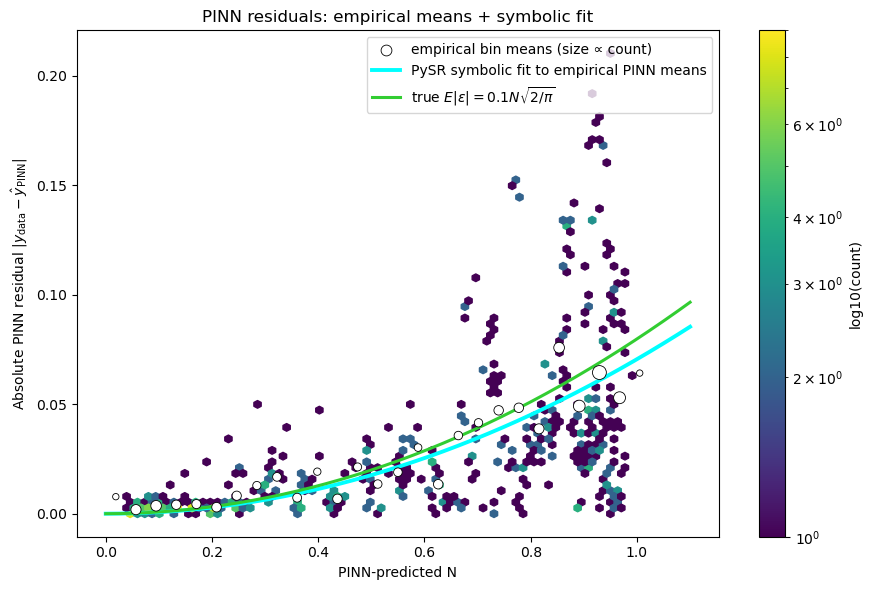

  - /var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/tmpxp1z_o0x/20260309_122333_eDrvwV/hall_of_fame.csv


In [8]:
from pysr import PySRRegressor

# ============================================================
# A. Build empirical means from PINN residuals
#    using the already-computed quantities:
#      N_pinn_sigma_all, resid_pinn_sigma_all, N_grid
# ============================================================
N_pinn_np = N_pinn_sigma_all.detach().cpu().numpy().reshape(-1)
abs_resid_pinn_np = np.abs(resid_pinn_sigma_all.detach().cpu().numpy().reshape(-1))

# choose bins over the support of the PINN-predicted states
N_max_fit = max(float(N_pinn_np.max()), float(N_grid.max().item()))
bins = np.linspace(0.0, N_max_fit, 30)
centers = 0.5 * (bins[:-1] + bins[1:])

means = []
counts = []

for i in range(len(bins) - 1):
    mask = (N_pinn_np >= bins[i]) & (N_pinn_np < bins[i + 1])
    if np.any(mask):
        means.append(abs_resid_pinn_np[mask].mean())
        counts.append(mask.sum())
    else:
        means.append(np.nan)
        counts.append(0)

means = np.array(means, dtype=np.float64)
counts = np.array(counts, dtype=np.float64)

valid = ~np.isnan(means)

X_emp_pinn = centers[valid][:, None]   # shape [n_bins_nonempty, 1]
Y_emp_pinn = means[valid]              # shape [n_bins_nonempty]
W_emp_pinn = counts[valid]             # weight by number of points in bin

print("Number of non-empty PINN bins:", len(X_emp_pinn))
print("Bin counts:", W_emp_pinn.astype(int))


# ============================================================
# B. Fit symbolic expression to empirical PINN mean residuals
#    weighted by bin counts
# ============================================================
pysr_model_pinn = PySRRegressor(
    niterations=10,
    populations=100,
   # population_size=10,
    maxsize=10,
    maxdepth=10,
    binary_operators=["+", "-", "*", "/"],
    #unary_operators=["exp", "log"],
    model_selection="best",
    loss="loss(prediction, target, weight) = weight * (prediction - target)^2",
    verbosity=1,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
)

pysr_model_pinn.fit(X_emp_pinn, Y_emp_pinn, weights=W_emp_pinn)

print("\nBest symbolic expression for PINN empirical mean residual:")
print(pysr_model_pinn.get_best())

print("ideal value", np.sqrt(2 / np.pi))
try:
    print("\nSympy form:")
    print(pysr_model_pinn.sympy())
except Exception:
    pass

try:
    print("\nLaTeX form:")
    print(pysr_model_pinn.latex())
except Exception:
    pass

def sigma_true(N):
    return 0.1 * N**2

sigma_grid_np = sigma_true(N_grid).squeeze(-1).cpu().numpy()
expected_abs = sigma_grid_np * np.sqrt(2 / np.pi)

# ============================================================
# C. Evaluate symbolic fit on the same N_grid used elsewhere
# ============================================================
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
symbolic_pinn_mean = pysr_model_pinn.predict(N_grid_np)


# ============================================================
# D. Optional reference curve from the known true noise law
#    Since data were generated with sigma(N)=0.1N and
#    E|epsilon| = sigma*sqrt(2/pi)
# ============================================================
expected_abs_true = sigma_grid_np * np.sqrt(2 / np.pi)


# ============================================================
# E. Plot: PINN absolute residuals + empirical means + symbolic fit
# ============================================================
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    N_pinn_np,
    abs_resid_pinn_np,
    gridsize=70,
    mincnt=1,
    bins="log"
)
plt.colorbar(hb, label="log10(count)")

marker_sizes = 20 + 80 * (W_emp_pinn / W_emp_pinn.max())
plt.scatter(
    X_emp_pinn[:, 0],
    Y_emp_pinn,
    s=marker_sizes,
    color="white",
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
    label="empirical bin means (size ∝ count)"
)

plt.plot(
    N_grid_np[:, 0],
    symbolic_pinn_mean,
    color="cyan",
    lw=2.8,
    label="PySR symbolic fit to empirical PINN means"
)

plt.plot(
    N_grid_np[:, 0],
    expected_abs_true,
    color="limegreen",
    lw=2.2,
    label=r"true $E|\epsilon| = 0.1N\sqrt{2/\pi}$"
)

plt.xlabel("PINN-predicted N")
plt.ylabel(r"Absolute PINN residual $|y_{\mathrm{data}}-\hat y_{\mathrm{PINN}}|$")
plt.title("PINN residuals: empirical means + symbolic fit")
plt.legend()
plt.tight_layout()
plt.show()


Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.05
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
PINN | Split  1/5 | Epoch     1/2000 | Train Total: 6.031854e-03 | Train Data: 5.933917e-01 | Train Phys: 4.192628e-03 | Train Anchor: 1.406801e-02 | lambda_data: 0.0031 | lambda_phys: 0.9969 | tau_data: 1.081590e+01 | tau_phys: 3.386834e-02 | Heldout Rollout Val: 3.510492e-01
PINN | Split  1/5 | Epoch   500/2000 | Train Total: 6.428595e-08 | Train Data: 4.561830e-01 | Train Phys: 6.368359e-08 | Train Anchor: 8.489870e-03 | lambda_data: 0.0000 | lambda_phys: 1.0000 | tau_data: 6.397018e+00 | tau_phys: 8.446865e-09 | Heldout Rollout Val: 3.375714e-01
PINN | Split  1/5 | Epoch  1000/2000 | Train Total: 2.932071e-08 | Train Data: 4.538198e-01 | Train Phys: 2.832084e-08 | Train Anchor: 8.435319e-03 | lambda_data: 0.0000 | lambda_phys: 1.0000 | tau_data: 6.384865e+00 | tau_ph

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_64893/266276667.py:172: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


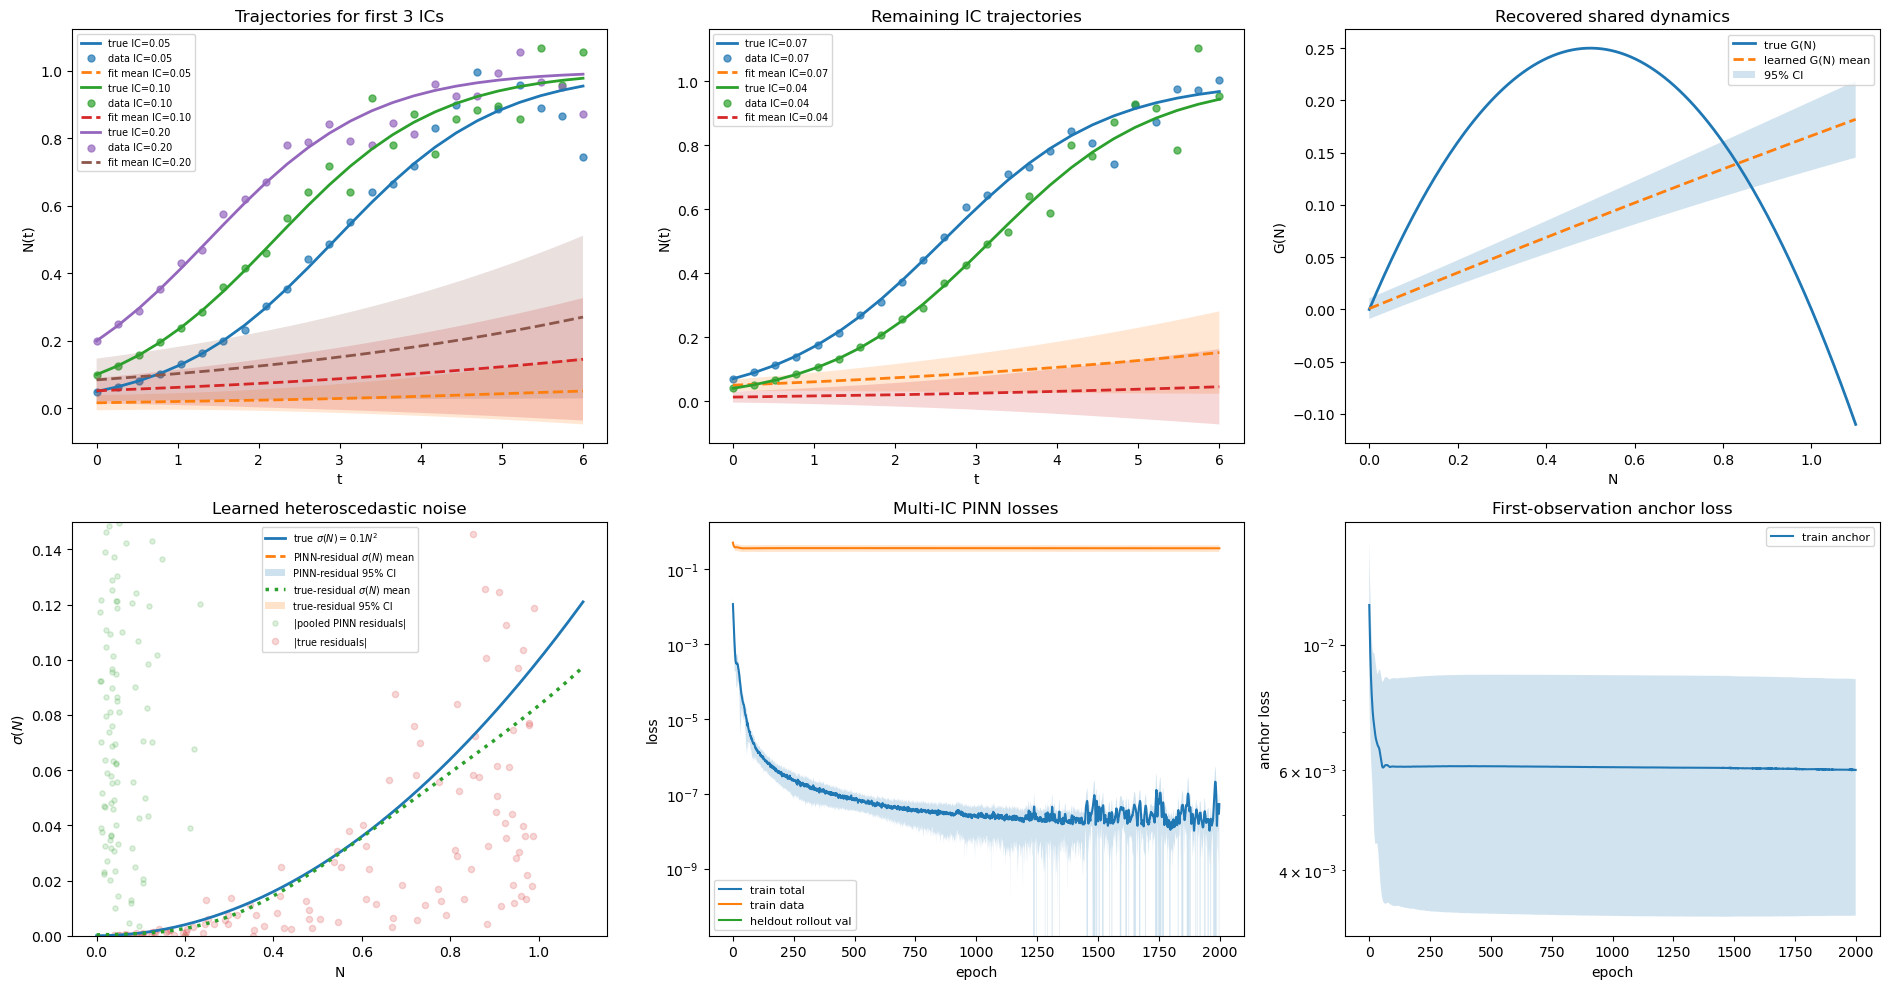

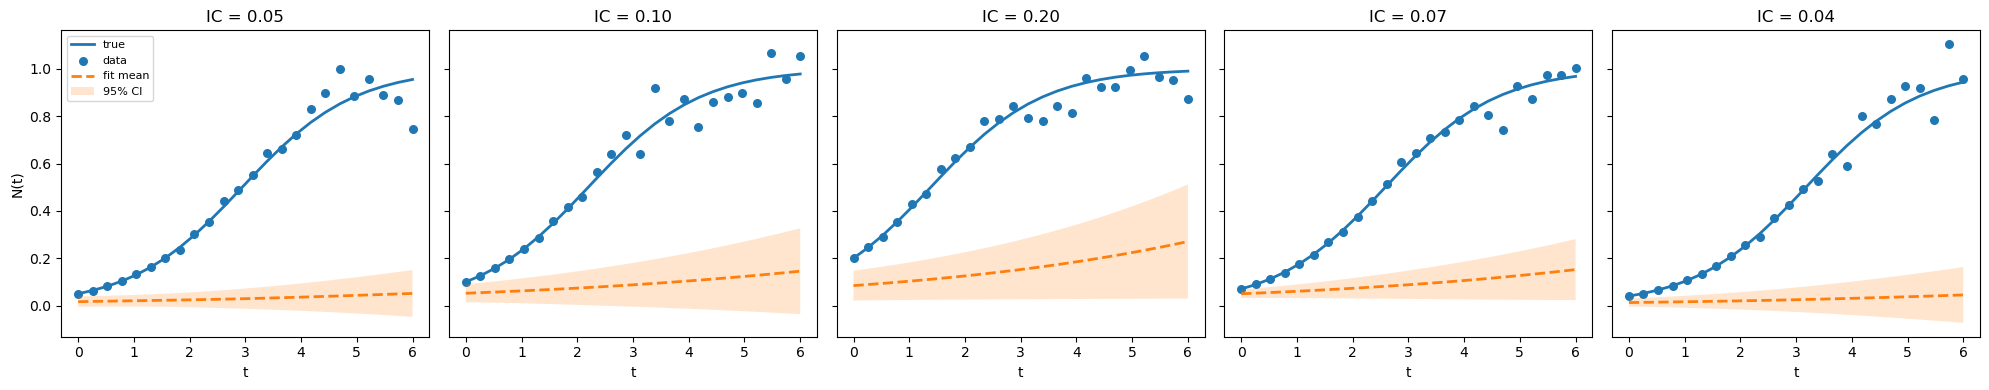

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_64893/266276667.py:1099: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


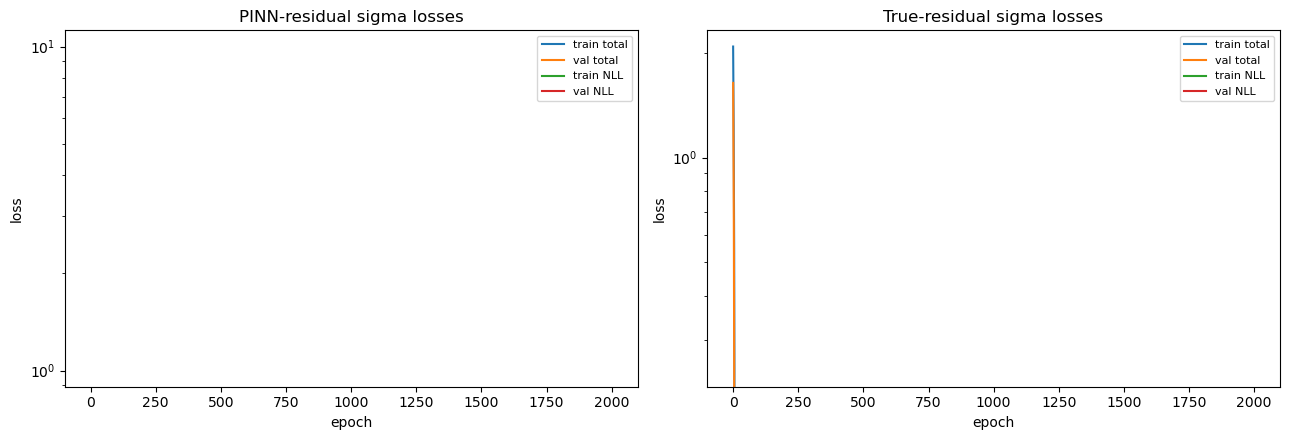


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 2.364797e-01
Std  best validation loss: 8.327597e-02
Mean best epoch: 959.00
Std  best epoch: 960.73
Anchor weight lambda_anchor: 0.000

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004]
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_seeds=[21000, 21002, 21003, 21004]
Split 3: heldout_ic=2, dyn_init_seed=10002, sol_init_seeds=[22000, 22001, 22003, 22004]
Split 4: heldout_ic=3, dyn_init_seed=10003, sol_init_seeds=[23000, 23001, 23002, 23004]
Split 5: heldout_ic=4, dyn_init_seed=10004, sol_init_seeds=[24000, 24001, 24002, 24003]

PINN-residual si

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


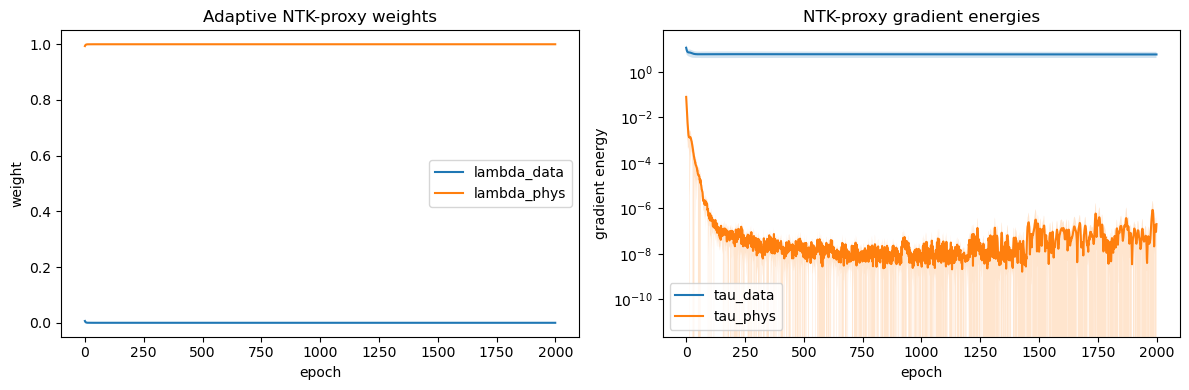

In [9]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04]#, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N^2
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


def grad_energy(loss, params):
    """
    Cheap proxy for NTK trace:
        || d(loss) / d(theta) ||_2^2

    This is not the exact empirical NTK trace, but it is much cheaper and
    works well for adaptive balancing of data and physics losses.
    """
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )
    out = torch.zeros((), device=loss.device)
    for g in grads:
        if g is not None:
            out = out + torch.sum(g.detach() ** 2)
    return out


def ntk_proxy_weights(tau_data, tau_phys, eps=1e-12):
    """
    Downweight the term with larger gradient energy.

    If tau_data is large, lambda_data becomes small.
    If tau_phys is large, lambda_phys becomes small.
    """
    denom = tau_data + tau_phys + eps
    lambda_data = tau_phys / denom
    lambda_phys = tau_data / denom
    return lambda_data.detach(), lambda_phys.detach()


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = np.nanmean(arr, axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        std = np.nanstd(arr, axis=0, ddof=1)
        n_eff = np.sum(~np.isnan(arr), axis=0)
        sem = np.divide(std, np.sqrt(np.maximum(n_eff, 1)), where=n_eff > 0)
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }

# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - adaptive NTK-style weighting using gradient-energy proxy
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 2000
n_splits = n_ics                 # one held-out trajectory per split
print_every = 500
val_every = 100                  # expensive rollout-based validation cadence

batch_obs = t_obs.shape[0]       # use all observation times for each training trajectory
batch_col = 100

lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_eval_mask_histories = []

lambda_data_histories = []
lambda_phys_histories = []
tau_data_histories = []
tau_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across training ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    lambda_data_history = []
    lambda_phys_history = []
    tau_data_history = []
    tau_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = torch.zeros((), device=device)
        total_phys_loss = torch.zeros((), device=device)
        total_anchor_loss = torch.zeros((), device=device)

        total_tau_data = torch.zeros((), device=device)
        total_tau_phys = torch.zeros((), device=device)

        # ----------------------------------------------------
        # Train only on non-held-out trajectories
        # ----------------------------------------------------
        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            # observation mini-batch from this trajectory
            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # optional anchor to first observed point
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss = total_data_loss + data_loss
            total_phys_loss = total_phys_loss + phys_loss
            total_anchor_loss = total_anchor_loss + anchor_loss

            # --------------------------------------------
            # NTK-style proxy using gradient energy
            # --------------------------------------------
            params_this_ic = list(dyn_net.parameters()) + list(sol_net.parameters())

            tau_data_i = grad_energy(data_loss, params_this_ic)
            tau_phys_i = grad_energy(phys_loss, params_this_ic)

            total_tau_data = total_tau_data + tau_data_i
            total_tau_phys = total_tau_phys + tau_phys_i

        total_data_loss = total_data_loss / n_train_ics
        total_phys_loss = total_phys_loss / n_train_ics
        total_anchor_loss = total_anchor_loss / n_train_ics

        total_tau_data = total_tau_data / n_train_ics
        total_tau_phys = total_tau_phys / n_train_ics

        lambda_data_ntk, lambda_phys_ntk = ntk_proxy_weights(
            total_tau_data, total_tau_phys
        )

        train_loss = (
            lambda_data_ntk * total_data_loss
            + lambda_phys_ntk * total_phys_loss
            + lambda_anchor * total_anchor_loss
        )
        train_loss.backward()
        optimizer.step()

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        lambda_data_history.append(lambda_data_ntk.item())
        lambda_phys_history.append(lambda_phys_ntk.item())
        tau_data_history.append(total_tau_data.item())
        tau_phys_history.append(total_tau_phys.item())

        # ----------------------------------------------------
        # Held-out trajectory validation via forward rollout
        # ----------------------------------------------------
        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                # start held-out rollout from its first observed value
                y0_val = y_data_all[heldout_ic][0:1]            # shape [1, 1]
                y_val_target = y_data_all[heldout_ic]           # shape [numpts, 1]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"Train Total: {train_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train Anchor: {total_anchor_loss.item():.6e} | "
                f"lambda_data: {lambda_data_ntk.item():.4f} | "
                f"lambda_phys: {lambda_phys_ntk.item():.4f} | "
                f"tau_data: {total_tau_data.item():.6e} | "
                f"tau_phys: {total_tau_phys.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                # held-out trajectory comes purely from forward solve of learned RHS
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    lambda_data_histories.append(lambda_data_history)
    lambda_phys_histories.append(lambda_phys_history)
    tau_data_histories.append(tau_data_history)
    tau_phys_histories.append(tau_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

lambda_data_histories = np.array(lambda_data_histories)
lambda_phys_histories = np.array(lambda_phys_histories)
tau_data_histories = np.array(tau_data_histories)
tau_phys_histories = np.array(tau_phys_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)

# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
#    Note: for held-out trajectories inside each split, N_hat comes from
#          forward solving the learned RHS, not a solution net.
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_ntk = np.arange(n_epochs)

lambda_data_mean, lambda_data_lo, lambda_data_hi = mean_and_ci(lambda_data_histories)
lambda_phys_mean, lambda_phys_lo, lambda_phys_hi = mean_and_ci(lambda_phys_histories)

tau_data_mean, tau_data_lo, tau_data_hi = mean_and_ci(tau_data_histories)
tau_phys_mean, tau_phys_lo, tau_phys_hi = mean_and_ci(tau_phys_histories)

axes[0].plot(epochs_ntk, lambda_data_mean, label="lambda_data")
axes[0].fill_between(epochs_ntk, lambda_data_lo, lambda_data_hi, alpha=0.2)
axes[0].plot(epochs_ntk, lambda_phys_mean, label="lambda_phys")
axes[0].fill_between(epochs_ntk, lambda_phys_lo, lambda_phys_hi, alpha=0.2)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weight")
axes[0].set_title("Adaptive NTK-proxy weights")
axes[0].legend()

axes[1].plot(epochs_ntk, tau_data_mean, label="tau_data")
axes[1].fill_between(epochs_ntk, tau_data_lo, tau_data_hi, alpha=0.2)
axes[1].plot(epochs_ntk, tau_phys_mean, label="tau_phys")
axes[1].fill_between(epochs_ntk, tau_phys_lo, tau_phys_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("gradient energy")
axes[1].set_title("NTK-proxy gradient energies")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def empirical_ntk_trace(outputs, params):
    """
    Full empirical NTK trace:
        Tr(K) = ||J||_F^2
    where J = d(outputs)/d(theta).

    outputs: tensor of shape [m, ...]
    params: iterable of parameters

    Returns a scalar tensor.
    """
    outputs_flat = outputs.reshape(-1)
    trace = torch.zeros((), device=outputs.device)

    for k in range(outputs_flat.numel()):
        grads = torch.autograd.grad(
            outputs_flat[k],
            params,
            retain_graph=True,
            create_graph=False,
            allow_unused=True,
        )
        for g in grads:
            if g is not None:
                trace = trace + torch.sum(g.detach() ** 2)

    return trace


def ntk_weights_from_traces(tau_data, tau_phys, eps=1e-12):
    """
    Downweight the term with larger NTK trace.
    """
    denom = tau_data + tau_phys + eps
    lambda_data = tau_phys / denom
    lambda_phys = tau_data / denom
    return lambda_data.detach(), lambda_phys.detach()



import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04]#, 0.03, 0.05]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N^2
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**2

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2


def grad_energy(loss, params):
    """
    Cheap proxy for NTK trace:
        || d(loss) / d(theta) ||_2^2

    This is not the exact empirical NTK trace, but it is much cheaper and
    works well for adaptive balancing of data and physics losses.
    """
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )
    out = torch.zeros((), device=loss.device)
    for g in grads:
        if g is not None:
            out = out + torch.sum(g.detach() ** 2)
    return out


def ntk_proxy_weights(tau_data, tau_phys, eps=1e-12):
    """
    Downweight the term with larger gradient energy.

    If tau_data is large, lambda_data becomes small.
    If tau_phys is large, lambda_phys becomes small.
    """
    denom = tau_data + tau_phys + eps
    lambda_data = tau_phys / denom
    lambda_phys = tau_data / denom
    return lambda_data.detach(), lambda_phys.detach()


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = np.nanmean(arr, axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        std = np.nanstd(arr, axis=0, ddof=1)
        n_eff = np.sum(~np.isnan(arr), axis=0)
        sem = np.divide(std, np.sqrt(np.maximum(n_eff, 1)), where=n_eff > 0)
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=100,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=10,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - adaptive NTK weighting using full empirical NTK trace
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 2000
n_splits = n_ics                 # one held-out trajectory per split
print_every = 100
val_every = 100                  # expensive rollout-based validation cadence

batch_obs = t_obs.shape[0]       # use all observation times for each training trajectory
batch_col = 100

lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_eval_mask_histories = []

lambda_data_histories = []
lambda_phys_histories = []
tau_data_histories = []
tau_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across training ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    lambda_data_history = []
    lambda_phys_history = []
    tau_data_history = []
    tau_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = torch.zeros((), device=device)
        total_phys_loss = torch.zeros((), device=device)
        total_anchor_loss = torch.zeros((), device=device)

        total_tau_data = torch.zeros((), device=device)
        total_tau_phys = torch.zeros((), device=device)

        # ----------------------------------------------------
        # Train only on non-held-out trajectories
        # ----------------------------------------------------
        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            # observation mini-batch from this trajectory
            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # optional anchor to first observed point
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss = total_data_loss + data_loss
            total_phys_loss = total_phys_loss + phys_loss
            total_anchor_loss = total_anchor_loss + anchor_loss

            if (epoch + 1) % 400 == 0:
                # ------------------------------:--------------
                # Full empirical NTK traces
                # --------------------------------------------
                params_this_ic = list(dyn_net.parameters()) + list(sol_net.parameters())

                tau_data_i = empirical_ntk_trace(N_pred_train, params_this_ic)
                tau_phys_i = empirical_ntk_trace(phys_res, params_this_ic)

                total_tau_data = total_tau_data + tau_data_i
                total_tau_phys = total_tau_phys + tau_phys_i

        total_data_loss = total_data_loss / n_train_ics
        total_phys_loss = total_phys_loss / n_train_ics
        total_anchor_loss = total_anchor_loss / n_train_ics

        total_tau_data = total_tau_data / n_train_ics
        total_tau_phys = total_tau_phys / n_train_ics

        lambda_data_ntk, lambda_phys_ntk = ntk_weights_from_traces(
            total_tau_data, total_tau_phys
        )

        train_loss = (
            1 * total_data_loss
            + 1 * total_phys_loss
            + lambda_anchor * total_anchor_loss
        )
        train_loss.backward()
        optimizer.step()

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        lambda_data_history.append(lambda_data_ntk.item())
        lambda_phys_history.append(lambda_phys_ntk.item())
        tau_data_history.append(total_tau_data.item())
        tau_phys_history.append(total_tau_phys.item())

        # ----------------------------------------------------
        # Held-out trajectory validation via forward rollout
        # ----------------------------------------------------
        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                # start held-out rollout from its first observed value
                y0_val = y_data_all[heldout_ic][0:1]            # shape [1, 1]
                y_val_target = y_data_all[heldout_ic]           # shape [numpts, 1]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"Train Total: {train_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train Anchor: {total_anchor_loss.item():.6e} | "
                f"lambda_data: {lambda_data_ntk.item():.4f} | "
                f"lambda_phys: {lambda_phys_ntk.item():.4f} | "
                f"tau_data: {total_tau_data.item():.6e} | "
                f"tau_phys: {total_tau_phys.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                # held-out trajectory comes purely from forward solve of learned RHS
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    lambda_data_histories.append(lambda_data_history)
    lambda_phys_histories.append(lambda_phys_history)
    tau_data_histories.append(tau_data_history)
    tau_phys_histories.append(tau_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

lambda_data_histories = np.array(lambda_data_histories)
lambda_phys_histories = np.array(lambda_phys_histories)
tau_data_histories = np.array(tau_data_histories)
tau_phys_histories = np.array(tau_phys_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)
# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
#    Note: for held-out trajectories inside each split, N_hat comes from
#          forward solving the learned RHS, not a solution net.
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_ntk = np.arange(n_epochs)

lambda_data_mean, lambda_data_lo, lambda_data_hi = mean_and_ci(lambda_data_histories)
lambda_phys_mean, lambda_phys_lo, lambda_phys_hi = mean_and_ci(lambda_phys_histories)

tau_data_mean, tau_data_lo, tau_data_hi = mean_and_ci(tau_data_histories)
tau_phys_mean, tau_phys_lo, tau_phys_hi = mean_and_ci(tau_phys_histories)

axes[0].plot(epochs_ntk, lambda_data_mean, label="lambda_data")
axes[0].fill_between(epochs_ntk, lambda_data_lo, lambda_data_hi, alpha=0.2)
axes[0].plot(epochs_ntk, lambda_phys_mean, label="lambda_phys")
axes[0].fill_between(epochs_ntk, lambda_phys_lo, lambda_phys_hi, alpha=0.2)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weight")
axes[0].set_title("Adaptive NTK-proxy weights")
axes[0].legend()

axes[1].plot(epochs_ntk, tau_data_mean, label="tau_data")
axes[1].fill_between(epochs_ntk, tau_data_lo, tau_data_hi, alpha=0.2)
axes[1].plot(epochs_ntk, tau_phys_mean, label="tau_phys")
axes[1].fill_between(epochs_ntk, tau_phys_lo, tau_phys_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("gradient energy")
axes[1].set_title("NTK-proxy gradient energies")
axes[1].legend()

plt.tight_layout()
plt.show()


Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.05
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
PINN | Split  1/5 | Epoch     1/2000 | Train Total: 0.000000e+00 | Train Data: 5.933917e-01 | Train Phys: 4.192628e-03 | Train Anchor: 1.406801e-02 | lambda_data: 0.0000 | lambda_phys: 0.0000 | tau_data: 0.000000e+00 | tau_phys: 0.000000e+00 | Heldout Rollout Val: 3.315412e-01
PINN | Split  1/5 | Epoch   100/2000 | Train Total: 0.000000e+00 | Train Data: 5.933917e-01 | Train Phys: 4.318757e-03 | Train Anchor: 1.406801e-02 | lambda_data: 0.0000 | lambda_phys: 0.0000 | tau_data: 0.000000e+00 | tau_phys: 0.000000e+00 | Heldout Rollout Val: 3.315412e-01
PINN | Split  1/5 | Epoch   200/2000 | Train Total: 0.000000e+00 | Train Data: 5.933917e-01 | Train Phys: 3.812166e-03 | Train Anchor: 1.406801e-02 | lambda_data: 0.0000 | lambda_phys: 0.0000 | tau_data: 0.000000e+00 | tau_ph

KeyboardInterrupt: 